# 08 — Noise x Attack Composition Sweep

**Purpose.** This is the notebook that actually answers the thesis's
**main research question** ("how does NISQ hardware noise affect the
adversarial robustness of variational hybrid quantum-classical ML
models?") and sub-RQ(a)/(b) for adversarial robustness specifically --
`06_noise_models` and `07_fgsm_attack` each answer a narrower question
in isolation (noise alone, attacks alone).

**Method.** FGSM adversarial examples are generated **once per
(seed, epsilon)** against the clean (noiseless) model's gradient --
the "deployable, attacker-knowable" model -- then those *same fixed*
adversarial examples are evaluated under each of the 14 noise
conditions from `06_noise_models` at inference time.

**Why not attack a noise-affected model directly?** A deliberate scope
decision, not an oversight: ART's FGSM needs a differentiable,
deterministic forward pass. A shot-based Aer forward pass under noise
is stochastic and not straightforwardly differentiable through the
parameter-shift chain, so building an adaptive noise-aware attacker
would be a substantially larger engineering effort than this thesis's
timeline supports. This design measures attack **transfer** under
hardware noise, matching the framing already used by Winderl et al.
(2024) and West et al. (2023) (both in the proposal's bibliography) --
not an adaptive attacker.

**Grid**: 8 seeds x 7 epsilons x 14 noise conditions = 784 evaluations,
on the same class-stratified 500-sample subsample used in
`07_fgsm_attack.ipynb`.

**A methodological caveat worth stating up front**: at `epsilon=0.0`,
predictions still go through the shot-based Aer pipeline (even under
`noise_model=None`), which introduces small residual sampling noise
relative to the exact `StatevectorEstimator` reference used elsewhere.
This means the `epsilon=0.0` row measures "how often does noise alone
(plus residual shot sampling) flip an originally-correct prediction" --
not "attack success" in any meaningful sense (there's no attack at
epsilon=0). Confirmed below: `attack_success_rate` at `epsilon=0.0`
rises with noise level in exactly the way plain misclassification rate
should, not in the more complex, sometimes-non-monotonic way real
epsilon>0 attacks behave. Interpret `epsilon=0.0` as a noise-only
control row, not as part of the adversarial-robustness story.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Work\Quantum-Adversarial-Robustness


## Results (8 seeds x 7 epsilons x 14 noise conditions = 784 rows)

In [2]:
df = pd.read_csv(PROJECT_ROOT / "results" / "noise_attack_sweep" / "noise_attack_sweep_all_seeds.csv")
print("rows:", len(df))

LEVEL_ORDER = ["L0", "L1", "L2", "L3", "L4"]


def with_l0(noise_type):
    # Combine a noise type's L1-L4 rows with the shared 'none'/L0
    # row (relabeled to that type's L0) for a complete L0-L4 view.
    sub = df[df["noise_type"].isin([noise_type, "none"])].copy()
    sub["level"] = sub.apply(lambda r: "L0" if r["noise_type"] == "none" else r["level"], axis=1)
    return sub


print("=== epsilon=0.0 (noise-only control -- NOT an attack) ===")
control = with_l0("depolarizing")
control = control[control["epsilon"] == 0.0]
print(control.pivot_table(index="level", values="attack_success_rate", aggfunc="mean").reindex(LEVEL_ORDER))

rows: 784
=== epsilon=0.0 (noise-only control -- NOT an attack) ===
       attack_success_rate
level                     
L0                0.035646
L1                0.047003
L2                0.056468
L3                0.153728
L4                0.342184


**Confirms the caveat above**: at `epsilon=0.0`, "attack success
rate" rises monotonically and substantially with noise level
(depolarizing L0->L4) -- exactly the plain noise-degradation pattern
already seen in `06_noise_models`, not an adversarial-robustness
effect. This row is a control, not a result.

## Attack success rate: epsilon x noise level, per noise type

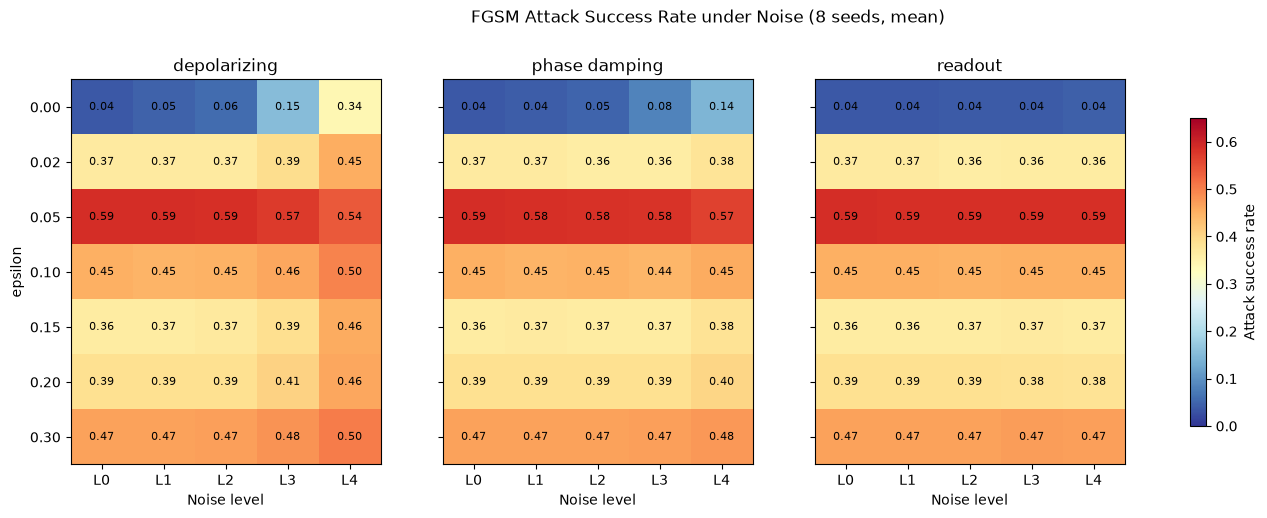

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

EPSILONS = sorted(df["epsilon"].unique())
noise_types = ["depolarizing", "phase_damping", "readout"]

for ax, noise_type in zip(axes, noise_types):
    sub = with_l0(noise_type)
    pivot = sub.pivot_table(index="epsilon", columns="level", values="attack_success_rate", aggfunc="mean")
    pivot = pivot.reindex(columns=[c for c in LEVEL_ORDER if c in pivot.columns])

    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=0.65)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{e:.2f}" for e in pivot.index])
    ax.set_xlabel("Noise level")
    ax.set_title(noise_type.replace("_", " "))

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center", fontsize=8)

axes[0].set_ylabel("epsilon")
fig.colorbar(im, ax=axes, label="Attack success rate", shrink=0.8)
fig.suptitle("FGSM Attack Success Rate under Noise (8 seeds, mean)", y=1.02)

fig.savefig(PROJECT_ROOT / "results" / "noise_attack_sweep" / "attack_success_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation

Excluding the `epsilon=0.0` control row, the noise-attack interaction
is **type-dependent and, for depolarizing noise, epsilon-dependent**:

- **Readout**: essentially no interaction with attack success at any
  epsilon or level -- consistent with readout's negligible effect on
  plain accuracy in `06_noise_models`. Readout error simply doesn't
  meaningfully perturb this VQC's decision boundary or its
  vulnerability to FGSM.
- **Phase damping**: a small, fairly consistent *increase* in attack
  success with noise level across most epsilons (e.g. epsilon=0.02:
  36.7%->38.0% from L0->L4), except at epsilon=0.05 where it mildly
  *decreases* (58.8%->56.6%).
- **Depolarizing**: the strongest and most epsilon-dependent effect.
  At most epsilons (0.02, 0.10, 0.15, 0.20, 0.30), higher depolarizing
  noise **increases** attack success rate, sometimes substantially
  (epsilon=0.02: 36.7%->45.3% from L0->L4). But at epsilon=0.05 --
  precisely the epsilon where the *noiseless* model is most vulnerable
  (peak attack success in `07_fgsm_attack`) -- higher depolarizing
  noise **decreases** attack success (58.8%->54.0%).

**This directly engages with the "dual impact of NISQ noise" question
in the current literature** (see the closest related paper, Entropy
2026, "Decoupling the Dual Impact of NISQ Noise on Quantum Adversarial
Robustness": "for some datasets, higher noise does suppress attacks,
whereas for others attacks remain effective... and in several cases a
moderate noise level even maximizes the attack success rate"). This
thesis's own data shows the *same* dual character **within a single
model and dataset**, depending on which attack strength is examined --
depolarizing noise is mostly a vulnerability-*increasing* factor, but
becomes a mild vulnerability-*decreasing* factor specifically at the
model's most-attacked epsilon. This is a genuine, nuanced finding
worth its own discussion section, not a result to average into a
single "noise helps" or "noise hurts" headline number.

**Answer to the main RQ / sub-RQ(a)/(b)**: NISQ noise's effect on
adversarial robustness is not uniform -- it depends on both noise type
(depolarizing >> phase damping >> readout, matching the noise-only
ranking) and, for the strongest noise type, on the specific attack
strength being defended against. A single "noise makes this model more
[or less] robust" claim would misrepresent the data; the honest answer
is conditional on both factors.

## Next

`09_mitigation.ipynb` (droppable if time runs short, per the thesis
architecture) applies readout calibration and zero-noise extrapolation
on top of these noise conditions. `10_statistical_analysis.ipynb` runs
the formal paired significance tests (Wilcoxon, FDR-corrected) across
seeds for the headline comparisons: hybrid vs. classical (RQ-e), and
noise-condition-vs-noise-condition for RQ(a)-(c).